# CIFAR-10 Image Classification with Keras

## Purpose

This notebook demonstrates the process of building and training Convolutional Neural Networks (CNNs) using Keras for image classification on the CIFAR-10 dataset. It covers data loading, exploratory data analysis, data preprocessing, and the development of different model architectures (ANN, simple CNN, and an enhanced CNN) to improve classification accuracy.

## 1.Importing the necessary libraries.

In [2]:
# Import Libraries
import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 2. Data Loading and Initial Exploration

This section loads the CIFAR-10 dataset using Keras and performs initial checks on its shape and content to understand the data structure.

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
assert X_train.shape == (50000, 32, 32, 3)
assert X_test.shape == (10000, 32, 32, 3)
assert y_train.shape == (50000, 1)
assert y_test. shape == (10000, 1)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1453s 9us/step


##3. Exploratory Data Analysis (EDA)

Here, we visualize sample images from each class to gain insights into the dataset's visual characteristics. A helper function is defined to display images for a given class.

In [4]:
y_train[0]

array([6], dtype=uint8)

In [5]:
label_dict =  {0:'airplane', 1:'automobile', 2:'bird', 3:'cat', 4:'deer', 5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

- creating the label for the number

### 3.1 Displaying Sample Images

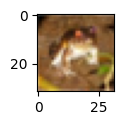

In [6]:
plt.figure(figsize=(1,1))
plt.imshow(X_train[0])

In [7]:
 list(range(10))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

- Checking the range of the output labels.

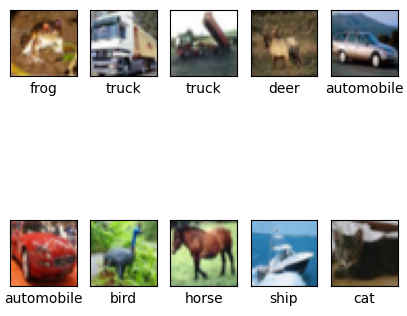

In [8]:
# Subplot of 2 x 5 where i want to print 10 images from different class
plt.figure(figsize=(5,5))

for i in range(10):
  plt.subplot(2, 5, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(X_train[i])
  plt.xlabel(label_dict.get(y_train[i][0]))

### 3.2 Creating the function to display the images with labels.

In [9]:
# Write a function which takes the class_name and additional argument which tells number of images, and you need to print images belonging to that class

def print_image_class(class_name="frog", number=10):

  class_index = class_names.index(class_name)

  # Filter the data which had frog
  class_indices=np.where(y_train.flatten()==class_index)[0]

  #Random Samples of the class
  random_class_indices=np.random.choice(class_indices,number )



  for i in random_class_indices:
    plt.figure(figsize=(1,1))
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train[i])
    plt.xlabel(label_dict.get(y_train[i][0]))
    plt.show()



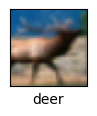

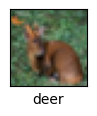

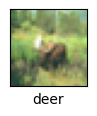

In [10]:
print_image_class(class_name="deer", number=3)

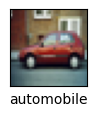

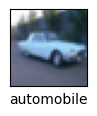

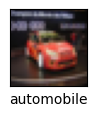

In [11]:
print_image_class(class_name="automobile", number=3)

## 4. Data Preprocessing

Before training the models, the image pixel values are normalized to a range of 0 to 1. This helps in faster and more stable training of neural networks.

In [12]:
# Resclae your data
max(X_train[00].flatten()),min(X_train[00].flatten())

(np.uint8(255), np.uint8(0))

- Finding the range of each image in the dataset.

### 4.1 Normalisation of Pixel Values

In [13]:
# Normalize
X_train_normalize = X_train/255.0
X_test_normalize = X_test/255.0

In [14]:
X_train[0].shape

(32, 32, 3)

## 5. Model Development

This section builds and trains three different models: a simple Artificial Neural Network (ANN), a basic Convolutional Neural Network (CNN), and an enhanced CNN. Each model's architecture, compilation, training, and performance visualization are presented.

### 5.1 Model-1: Artificial Neural Network (ANN)

This is a simple ANN model using `Flatten` layers to convert the 2D image data into a 1D vector before passing it to densely connected layers. It serves as a baseline for comparison.

In [15]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32, 32,3)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,250 (1.53 MB)

 Trainable params: 402,250 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.1.1 Compile Model-1

In [16]:
model.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


#### 5.1.2 Train Model-1

In [17]:
# Train the model
history=model.fit(X_train_normalize,y_train,epochs=10,validation_data=(X_test_normalize,y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.2804 - loss: 1.9814 - val_accuracy: 0.3518 - val_loss: 1.8146
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3551 - loss: 1.8115 - val_accuracy: 0.3841 - val_loss: 1.7199
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3815 - loss: 1.7422 - val_accuracy: 0.3949 - val_loss: 1.6909
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3975 - loss: 1.6936 - val_accuracy: 0.4117 - val_loss: 1.6522
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4122 - loss: 1.6575 - val_accuracy: 0.4244 - val_loss: 1.6145
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4232 - loss: 1.6263 - val_accuracy: 0.4499 - val_loss: 1.5580
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4302 - loss: 1.5994 - val_accuracy: 0.4494 - val_loss: 1.5447
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4391 - loss: 1.5769 -

## Model-2 CNN

### 5.2 Model-2: Basic Convolutional Neural Network (CNN)

This model introduces convolutional layers, which are more effective for image data by learning spatial hierarchies. It includes `Conv2D`, `BatchNormalization`, `MaxPooling2D`, and `Dense` layers.

In [18]:
# Create a CNN model-1
model = keras.Sequential([
    keras.layers.Conv2D(20,(3,3),activation='relu',input_shape=(32,32,3)),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D((2,2)),


    keras.layers.Flatten(),


    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 20)     │           560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 20)     │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 20)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       576,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 578,058 (2.21 MB)

 Trainable params: 578,018 (2.20 MB)

 Non-trainable params: 40 (160.00 B)

#### 5.2.1 Compile Model-2

In [19]:
model.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#### 5.2.2 Train Model-2

In [20]:
# Train the model
history=model.fit(X_train_normalize,y_train,epochs=10,validation_data=(X_test_normalize,y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.4931 - loss: 1.4281 - val_accuracy: 0.5029 - val_loss: 1.4329
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6096 - loss: 1.1092 - val_accuracy: 0.5606 - val_loss: 1.2549
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6656 - loss: 0.9562 - val_accuracy: 0.6098 - val_loss: 1.1193
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7035 - loss: 0.8458 - val_accuracy: 0.5552 - val_loss: 1.3315
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7409 - loss: 0.7456 - val_accuracy: 0.6244 - val_loss: 1.1152
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7741 - loss: 0.6531 - val_accuracy: 0.5702 - val_loss: 1.4099
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8045 - loss: 0.5673 - val_accuracy: 0.5636 - val_loss: 1.5641
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8313 - loss: 0.4904 

#### 5.2.3 Visualize Training History for Model-2

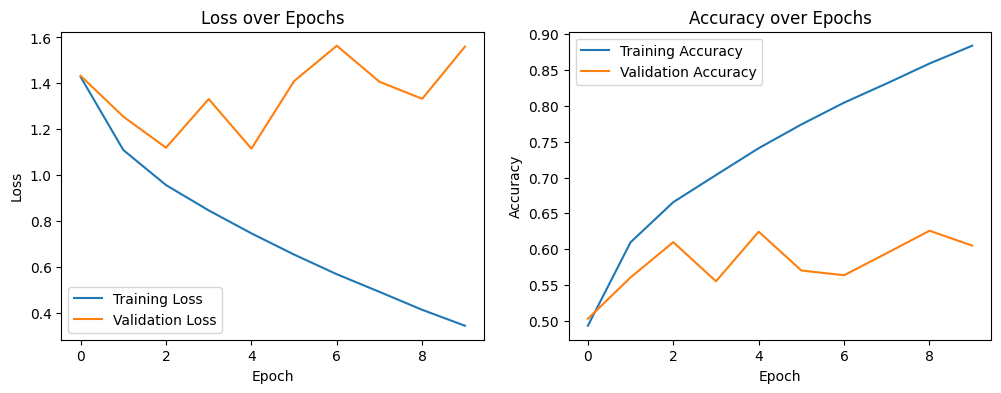

In [21]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

### 5.3 Model-3: Convolutional Neural Network (CNN)

This model introduces convolutional layers, which are more effective for image data by learning spatial hierarchies. It includes `Conv2D`, `BatchNormalization`, `MaxPooling2D`, `Dropout` and `Dense` layers.

In [24]:
# Create a CNN model-2
model = models.Sequential()
model.add(layers.Conv2D(32, (5, 5), padding='same', activation="relu", input_shape=(32,32,3)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.3))
model.add(layers.Conv2D(64, (5, 5), padding='same', activation="relu"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.4))

model.add(layers.Flatten())
model.add(layers.Dense(256, activation="relu"))
model.add(layers.Dropout(0.5))
# softmax
model.add(layers.Dense(10, activation="softmax"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,105,482 (4.22 MB)

 Trainable params: 1,105,290 (4.22 MB)

 Non-trainable params: 192 (768.00 B)

#### 5.3.1 Compile Model-3
- We are adding the optimiser `adam` and `learning rate` to the model for compilation.

In [25]:
# initiate Adam optimizer
from keras import optimizers
opt = optimizers.Adam(learning_rate=0.001)
# Let's train the model using RMSprop
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

#### 5.3.2 Train Model-3

In [26]:
# Train the model
history=model.fit(X_train,y_train,epochs=10,validation_data=(X_test,y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.3482 - loss: 1.8041 - val_accuracy: 0.4471 - val_loss: 1.5840
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.4737 - loss: 1.4563 - val_accuracy: 0.5472 - val_loss: 1.2793
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5376 - loss: 1.3025 - val_accuracy: 0.6297 - val_loss: 1.0594
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5807 - loss: 1.1984 - val_accuracy: 0.5777 - val_loss: 1.3563
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6071 - loss: 1.1236 - val_accuracy: 0.5289 - val_loss: 1.4996
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6310 - loss: 1.0576 - val_accuracy: 0.6755 - val_loss: 0.9282
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6538 - loss: 0.9957 - val_accuracy: 0.6432 - val_loss: 1.0102
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6715 - loss: 0.9454 -

#### 5.3.3 Visualise Training History for Model-3

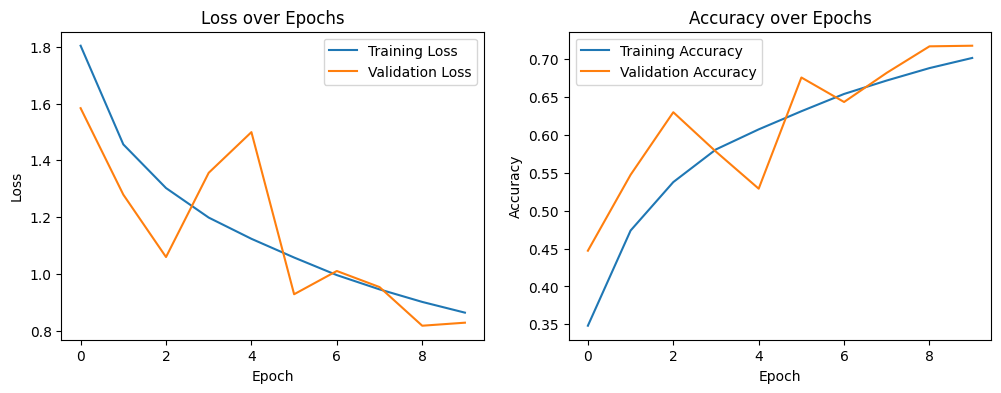

In [27]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

### Model-4 CNN (Enhanced)

This model builds upon the previous CNN architecture by adding more layers, increasing the number of filters/perceptrons, and incorporating advanced training techniques like Early Stopping and ReduceLROnPlateau to further fine-tune the model for better validation accuracy and reduced validation loss.

### 5.4 Model-4: Enhanced Convolutional Neural Network (CNN)

Building upon Model-3, this enhanced CNN (`Model-4`) incorporates additional convolutional blocks, increased filter counts, and advanced fine-tuning techniques such as `Dropout` layers for regularisation, `EarlyStopping` to prevent overfitting, and `ReduceLROnPlateau` for adaptive learning rate scheduling. The goal is to achieve higher validation accuracy and lower validation loss.

In [28]:
# Define an enhanced CNN model (Model-3)
model_3 = models.Sequential()

model_3.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)))
model_3.add(layers.BatchNormalization())
model_3.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
model_3.add(layers.BatchNormalization())
model_3.add(layers.MaxPooling2D((2, 2)))
model_3.add(layers.Dropout(0.3))

model_3.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
model_3.add(layers.BatchNormalization())
model_3.add(layers.MaxPooling2D((2, 2)))
model_3.add(layers.Dropout(0.4))

model_3.add(layers.Flatten())
model_3.add(layers.Dense(512, activation='relu'))
model_3.add(layers.Dropout(0.5))
model_3.add(layers.Dense(10, activation='softmax'))

model_3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,294,090 (16.38 MB)

 Trainable params: 4,293,642 (16.38 MB)

 Non-trainable params: 448 (1.75 KB)

#### 5.4.1 Compile Model-4 with Callbacks

In [29]:
from keras import optimizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Initiate Adam optimizer with a lower learning rate
opt_3 = optimizers.Adam(learning_rate=0.0005)

# Compile Model-3
model_3.compile(loss='sparse_categorical_crossentropy',
                optimizer=opt_3,
                metrics=['accuracy'])

# Callbacks for fine-tuning
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

#### 5.4.2 Train Model-4

In [30]:
# Train Model-3 with normalized data and callbacks
history_3 = model_3.fit(X_train_normalize, y_train, epochs=30,
                        validation_data=(X_test_normalize, y_test),
                        callbacks=[early_stopping, reduce_lr])

Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.4051 - loss: 1.6983 - val_accuracy: 0.5708 - val_loss: 1.2074 - learning_rate: 5.0000e-04
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.5482 - loss: 1.2630 - val_accuracy: 0.6293 - val_loss: 1.0769 - learning_rate: 5.0000e-04
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6153 - loss: 1.0941 - val_accuracy: 0.6709 - val_loss: 0.9317 - learning_rate: 5.0000e-04
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6552 - loss: 0.9931 - val_accuracy: 0.6649 - val_loss: 1.0688 - learning_rate: 5.0000e-04
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6819 - loss: 0.9129 - val_accuracy: 0.7323 - val_loss: 0.7726 - learning_rate: 5.0000e-04
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7058 - loss: 0.8504 - val_accuracy: 0.7351 - val_loss: 0.8057 - learning_rate: 5.0000e-04
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s

#### 5.4.3 Visualize Training History for Model-4

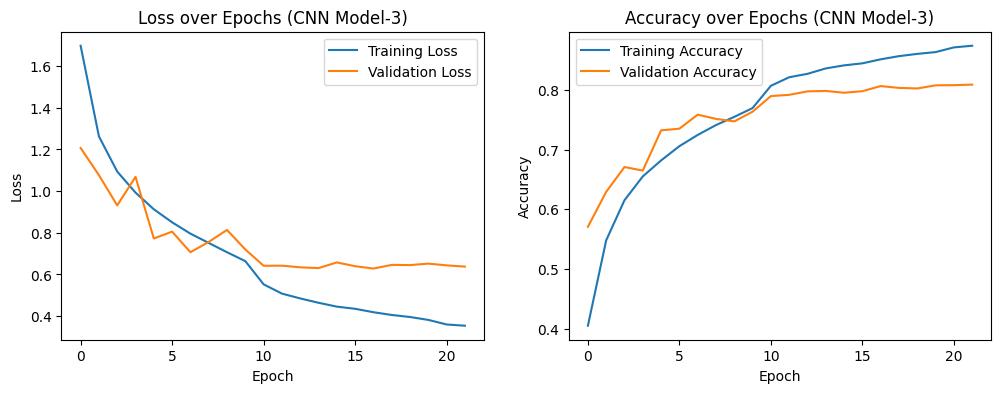

In [31]:
# Plotting training and validation loss and accuracy for CNN Model-3
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_3.history['loss'], label='Training Loss')
plt.plot(history_3.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs (CNN Model-3)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_3.history['accuracy'], label='Training Accuracy')
plt.plot(history_3.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs (CNN Model-3)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()